<a href="https://colab.research.google.com/github/KharismaAdhiguna/statistical-testing/blob/main/statistical_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

In [8]:
original_data = np.array([10.0, 11.0, 9.5, 14.0, 8.0, 12.0, 11.0, 13.0, 9.0, 11.5])
n = len(original_data)
np.random.seed(42)

bootstrap_iterations = 10000
bootstrap_means = np.zeros(bootstrap_iterations)

In [9]:
for i in range(bootstrap_iterations):
    bootstrap_sample = np.random.choice(original_data, size=n, replace=True)
    bootstrap_means[i] = np.mean(bootstrap_sample)
lower_limit = np.percentile(bootstrap_means, 2.5)
upper_limit = np.percentile(bootstrap_means, 97.5)

In [10]:
print("--- BOOTSTRAP RESULTS (10,000 Resamples) ---")
print(f"Original Sample Mean: {np.mean(original_data):.3f}")
print(f"Bootstrap 95% Lower Limit (2.5th percentile): {lower_limit:.3f}")
print(f"Bootstrap 95% Upper Limit (97.5th percentile): {upper_limit:.3f}")
print(f"Bootstrap 95% Confidence Interval: [{lower_limit:.3f} ~ {upper_limit:.3f}]")
print("-" * 45)

--- BOOTSTRAP RESULTS (10,000 Resamples) ---
Original Sample Mean: 10.900
Bootstrap 95% Lower Limit (2.5th percentile): 9.850
Bootstrap 95% Upper Limit (97.5th percentile): 11.950
Bootstrap 95% Confidence Interval: [9.850 ~ 11.950]
---------------------------------------------


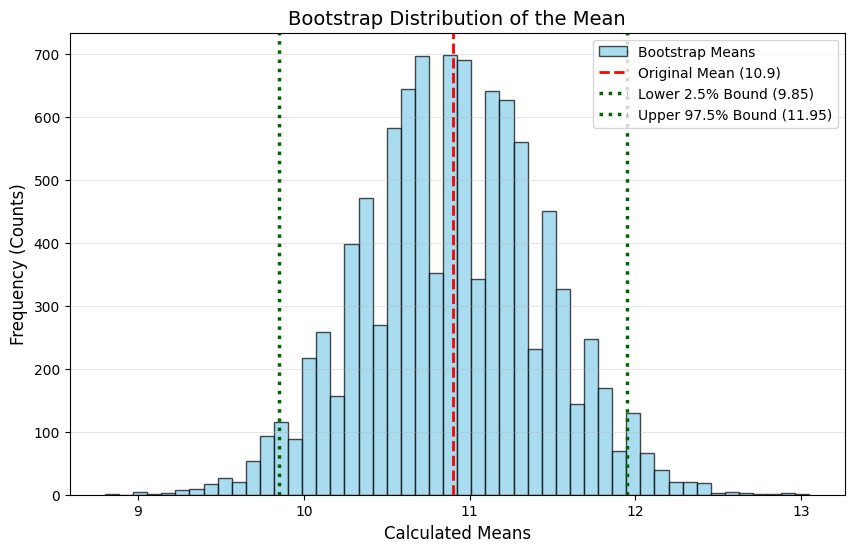

In [11]:
plt.figure(figsize=(10, 6))
plt.hist(bootstrap_means, bins=50, edgecolor='black', color='skyblue', alpha=0.7, label='Bootstrap Means')
plt.axvline(np.mean(original_data), color='red', linestyle='--', linewidth=2, label=f'Original Mean ({np.mean(original_data):.1f})')
plt.axvline(lower_limit, color='darkgreen', linestyle=':', linewidth=2.5, label=f'Lower 2.5% Bound ({lower_limit:.2f})')
plt.axvline(upper_limit, color='darkgreen', linestyle=':', linewidth=2.5, label=f'Upper 97.5% Bound ({upper_limit:.2f})')

plt.title('Bootstrap Distribution of the Mean', fontsize=14)
plt.xlabel('Calculated Means', fontsize=12)
plt.ylabel('Frequency (Counts)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()